# 🔍 Plataforma RCA — Detección de Anomalías en Microservicios (Fase 1)
**Descripción:** Este notebook contiene el pipeline definitivo para la detección no supervisada de anomalías e identificación de causa raíz (RCA) utilizando logs unificados por `traceId` procedentes del stack PLG (Loki).
**Modelo:** Isolation Forest + TF-IDF (NLP) + Standard Scaling.

---

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import shap
import json
import re
import os

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix

%matplotlib inline

/opt/homebrew/Caskroom/miniforge/base/envs/rca/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de Datos y Consolidación de Logs
En esta sección importamos los logs en crudo extraídos de Loki. Para reconstruir el ciclo de vida de cada petición y evitar la pérdida de contexto por condiciones de carrera en los hilos de logging:
1. Eliminamos las filas donde `event_type, http_uri y duration_ms` son nulos de manera conjunta. No serán de ayuda esas filas.
2. Eliminamos los endpoints de `CHAOS` generados para conseguir el dataset.
3. Creamos una nueva nueva feature `log_count` donde contamos los logs que se han generado por un mismo trace-id. Esta información le servirá al modelo para poder discernir entre una petición anómala y una normal
4. Juntamos los logs por su `traceid` para tener un único log con toda la información. Debemos de arreglar la columna `level` ya que fruto de juntar los logs, puede contener varios datos juntos

In [3]:
df_1 = pd.read_csv("../datasets/01_logs_dataset.csv")
df_2 = pd.read_csv("../datasets/02_logs_dataset.csv")
df = pd.concat([df_1, df_2], ignore_index=True)
df.head()

# Elimina filas donde event_type, http_uri y duration_ms son todos nulos Y quitamos outcome porque aporta redundancia
df = df.dropna(subset=["event_type", "duration_ms"], how="all")
df = df.drop(columns=["outcome"])

# Elimina también los endpoints de caos
df = df[~df["http_uri"].str.contains("/chaos/", na=False)]

# eliminamos las columnas que ya no sirven
cdf = df.drop(columns=["http_uri"])
print(len(cdf))

5265


In [4]:
df.head()

,@timestamp,service,level,event_type,http_method,http_uri,http_status,duration_ms,error_type,error_message,error_origin,traceId
0,2026-07-03T08:03:23.032Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/register,201.0,363.0,NaN,NaN,NaN,6a476cca227cf2c2a7778eea6814c767
1,2026-07-03T08:04:56.876Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,115.0,NaN,NaN,NaN,6a476d28bef605f56445e5f31a75ab8a
2,2026-07-03T08:04:59.767Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,108.0,NaN,NaN,NaN,6a476d2b308ea5cc0f8932e9de3ca02d
3,2026-07-03T08:05:04.616Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,107.0,NaN,NaN,NaN,6a476d30b15c719121fc2c7488b11b02
4,2026-07-03T08:05:06.940Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,87.0,NaN,NaN,NaN,6a476d323360f89f718e7343d5f6686b


In [3]:
# Contamos los logs que genero una misma peticion (conocemos que si son 2 suele ser fallo, puede ser una buena medida)
cdf['log_count'] = cdf.groupby(['traceId', 'service'])['traceId'].transform('count')
cdf['log_count'].value_counts()

log_count
2    2952
1    2313
Name: count, dtype: int64

In [4]:
# 1. Asegurarnos de que el dataframe esté ordenado por tiempo
cdf = cdf.sort_values(by=['@timestamp'])

# 2. PROPAGAR EL TRACEID: 
# Agrupamos por tiempo exacto y servicio, y propagamos el traceId hacia atrás (bfill) y hacia adelante (ffill)
# Así, la fila que tiene NaN adoptará el traceId '6a4bac01...' de su fila hermana.
cdf['traceId'] = cdf.groupby(['@timestamp', 'service'])['traceId'].transform(lambda x: x.bfill().ffill())

# Opcional pero recomendado: si queda algún log de sistema puro que no pertenece a ninguna 
# petición (sigue teniendo traceId = NaN), lo filtramos para no meter ruido al modelo.
cdf = cdf.dropna(subset=['traceId'])

# 3. EL DICCIONARIO DE AGREGACIÓN (El que ya teníamos)
agregaciones = {
    '@timestamp': 'min',  
    'level': lambda x: ', '.join(x.dropna().astype(str).unique()),
    'event_type': lambda x: ', '.join(x.dropna().astype(str).unique()),
    'http_method': 'first',
    'http_status': lambda x: ', '.join(x.dropna().astype(str).unique()),
    'duration_ms': 'sum', 
    'error_type': lambda x: ' | '.join(x.dropna().astype(str).unique()),
    'error_message': lambda x: ' | '.join(x.dropna().astype(str).unique()),
    'error_origin': lambda x: ' | '.join(x.dropna().astype(str).unique()),
    'log_count':'max'
}

# 4. AGRUPACIÓN FINAL
df_clear = cdf.groupby(['traceId', 'service']).agg(agregaciones).reset_index()

# arreglamos que ahora haya varios level en uno mismo
def max_level(comb_level):
    level = str(comb_level).upper()
    if 'ERROR' in level:
        return 'ERROR'
    elif 'WARN' in level:
        return 'WARN'
    else:
        return 'INFO'

df_clear['level'] = df_clear['level'].apply(max_level)

df_clear['level'].value_counts()

level
ERROR    2279
INFO     1510
Name: count, dtype: int64

#### 1.1 Ingeniería de Características
1. Creamos la columna `tiene_error_5xx` que tomarán valores binarios para indicar cuando una petición tiene un error de la familia 500. De esta forma, el modelo entiende de manera más fácil de qué se trata
2. Creamos una feature que se llama es_anomalia para poder hacer un entrenamiento semi-supervisado. Ademas rellenamos con X los valores nulos de `error_type` y `error_message` para poder aplicar el NPL sin problema. 
3. Creamos una feature nueva llamada `duracion_relativa` que indica cuánto se desvía la latencia partiendo de un baseline calculado por la media de aquellas peticiones que van a un determinado servicio
4. Creamos una feature nueva llamada `cascada` que indicara con `0´s` cuando el log NO ha sido generado por un error en casacada y `1´s` cuando si lo haya sido
5. Eliminamos las columnas `@timestamp, , service y uri_servicio"`

In [5]:
def etiquetado(fila):
    if '500' in str(fila['http_status']) or 'ERROR' in str(fila['level']):
        return -1
    else:
        return 1
        
df_clear['es_anomalia'] = df_clear.apply(etiquetado, axis=1)

# quitamos los valores nulos por X´s para que el TF-IDF no tenga problemas
df_clear['error_message'] = df_clear['error_message'].fillna('X')
df_clear['error_type'] = df_clear['error_type'].fillna('X')

# dejamos el texto entero para que lo procese nlp junto
def limpiar_texto(texto):
    if texto == "X" or pd.isna(texto):
        return ""
    
    texto = re.sub(r":\d+", "", texto)
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    return texto.lower().strip()

df_clear["texto_completo"] = (
    df_clear["error_type"].apply(limpiar_texto) + " " +
    df_clear["error_message"].apply(limpiar_texto) + " " +
    df_clear["error_origin"].apply(limpiar_texto)
)

df_clear['texto_completo'] = df_clear['error_type'] + " " + df_clear['error_message']
df_clear = df_clear.drop(columns=['error_type', 'error_message'])

print(df_clear['es_anomalia'].value_counts())

es_anomalia
-1    2279
 1    1510
Name: count, dtype: int64


In [6]:
df_clear['tiene_error_5xx'] = df_clear['http_status'].astype(str).str.contains(r'5\d{2}').astype(int)
df_clear = df_clear.drop(columns=['http_status'])
df_clear.columns

# linea base de la duraci'on relativ a
baseline = df_clear[df_clear["es_anomalia"] == 1].groupby("service")["duration_ms"].mean()

df_clear["duracion_relativa"] = df_clear.apply(
    lambda row: row["duration_ms"] / baseline.get(row["service"], 1),
    axis=1
)

# Marcamos las cascadas
def marcar_cascada(df):
    # Primero aplica max_level para tener el level final de cada fila
    df['level_final'] = df['level'].apply(max_level)
    
    # traceIds que tienen ERROR en al menos dos servicios distintos
    errores_por_trace = (
        df[df['level_final'] == 'ERROR']
        .groupby('traceId')['service']
        .nunique()
    )
    traces_cascada = errores_por_trace[errores_por_trace > 1].index
    df['is_cascada'] = df['traceId'].isin(traces_cascada).astype(int)
    
    return df

df_clear = marcar_cascada(df_clear)
df_clear = df_clear.drop(columns=["@timestamp", "service", "level_final"])

## Split de datos

In [8]:
X = df_clear.drop(columns=['es_anomalia'])
y = df_clear['es_anomalia']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

## 3. Arquitectura del Pipeline y ColumnTransformer
Para evitar fugas de datos (*data leakage*) y asegurar la reproducibilidad, construimos un enrutador de características. 
* **Numéricas:** Se procesan mediante `RobustScaler` (mediana y rango intercuartílico) para mitigar el peso desproporcionado de las latencias extremas producidas por los ataques de inyección.
* **Texto:** Se vectorizan con `TfidfVectorizer` limitando las dimensiones para evitar que el océano de palabras diluya el peso de las variables físicas.

In [12]:
categorical_scaler = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='constant', fill_value='NONE')),
    ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_scaler = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

level_pipeline = Pipeline(steps=[
    ('inputer', SimpleImputer(strategy='constant',fill_value='INFO')),
    ('ordinal', OrdinalEncoder(categories=[["INFO", "WARN", "ERROR"]]))
])

tf_pipeline = Pipeline(steps=[
    ('vectorizador', TfidfVectorizer())
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_scaler, ["event_type", "http_method"]),
    ("num", num_scaler, ["duration_ms", "duracion_relativa", "log_count"]),
    ("bin", "passthrough", ["tiene_error_5xx", "is_cascada"]),
    ("ord", level_pipeline, ["level"]),
    ('text_processor', tf_pipeline, "texto_completo"),
    ('text_processor_origin', tf_pipeline, "error_origin")
])

In [13]:
isolation_estimator = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', IsolationForest(random_state=42))
])

## 4. Optimización de Hiperparámetros (GridSearchCV)
Ejecutamos una optimización fina. Controlamos estrictamente el parámetro `max_features` del TF-IDF para balancear la probabilidad de selección de ramas en el árbol del Isolation Forest, garantizando que coexistan métricas de texto y métricas binarias de servidor.

In [22]:
param_grid = {
    # Ajustes para el TF-IDF
    'preprocessor__text_processor__vectorizador__max_features': [10, 30],
    'preprocessor__text_processor__vectorizador__ngram_range': [(1, 1), (1, 2)], # Probar palabras sueltas vs pares de palabras
    'preprocessor__text_processor__vectorizador__max_df': [0.7, 0.9],
    'preprocessor__text_processor__vectorizador__min_df': [1, 2],
    
    # Ajustes para el Isolation Forest
    'model__n_estimators': [100, 200],
    'model__contamination': [0.05, 0.10, 0.15, 0.20, 'auto']
}

In [23]:
anomalia_scorer=make_scorer(f1_score, pos_label=-1)

isolation_search = GridSearchCV(
    estimator=isolation_estimator,
    param_grid=param_grid,
    cv=5,
    n_jobs=1,
    scoring=anomalia_scorer
)

In [24]:
isolation_search.fit(X_train, y_train)
print(f"Mejores parámetros encontrados: {isolation_search.best_params_}")
print(f"Mejor F1-Score: {isolation_search.best_score_}")
best_isolation_model = isolation_search.best_estimator_

Mejores parámetros encontrados: {'model__contamination': 'auto', 'model__n_estimators': 200, 'preprocessor__text_processor__vectorizador__max_df': 0.7, 'preprocessor__text_processor__vectorizador__max_features': 30, 'preprocessor__text_processor__vectorizador__min_df': 1, 'preprocessor__text_processor__vectorizador__ngram_range': (1, 2)}
Mejor F1-Score: 0.8478945532668576


## 5. Evaluación del Modelo (Matriz de Confusión y Heatmap)
Graficamos la matriz de confusión mediante un mapa de calor de Seaborn para auditar el balance del modelo. Buscamos el punto dulce donde maximizamos el Recall (atrapando todas las inyecciones de caos) manteniendo controlados los Falsos Positivos para mitigar la fatiga de alertas.

<Axes: >

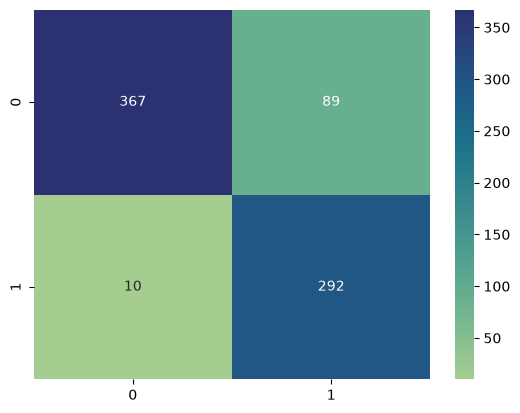

In [25]:
y_pred = best_isolation_model.predict(X_test)

cf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)
sns.heatmap(cf_matrix, annot=True, cmap='crest', fmt='d')

## 6. Interpretabilidad Global y Análisis RCA (SHAP Explainer)
Al ser un modelo basado en un bosque de aislamiento aleatorio, abrimos la caja negra utilizando teoría de juegos (SHAP). Esto nos permite mapear y nombrar cada dimensión matemática recuperada del preprocesador (incluyendo tokens de texto y métricas escaladas de severidad) para demostrar fehacientemente en qué variables se fundamentan las alertas del sistema.

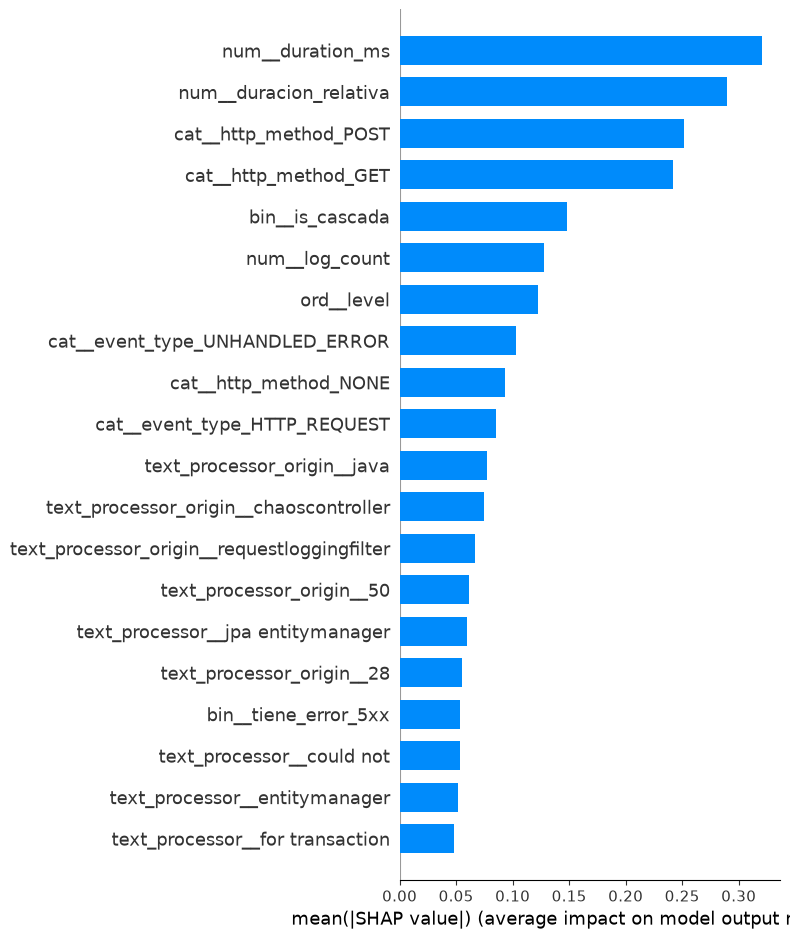

In [27]:
# cogemos el preprocesador y el modelo 
preproc_model=best_isolation_model.named_steps['preprocessor']
model_if=best_isolation_model.named_steps['model']

# cogemos el nombre de las colum y transofrmamos el test
nombre_features=preproc_model.get_feature_names_out()
X_test_transformado= preproc_model.transform(X_test)

explainer=shap.TreeExplainer(model_if)
shap_values=explainer.shap_values(X_test_transformado)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test_transformado, feature_names=nombre_features, plot_type="bar")

## Exportacion del modelo y parametros

In [31]:
MODELOS_DIR = os.path.join(os.getcwd(), "../modelos")
os.makedirs(MODELOS_DIR, exist_ok=True)

joblib.dump(isolation_search.best_estimator_, f"{MODELOS_DIR}/01_isolation_forest.pkl")

# Guarda también los metadatos del entrenamiento
metadatos = {
    "best_params":    isolation_search.best_params_,
    "best_score":     isolation_search.best_score_,
    "features":       list(X_train.columns),
    "fecha_entreno":  pd.Timestamp.now().isoformat(),
    "n_train":        len(X_train),
    "n_test":         len(X_test),
    "contaminacion":  isolation_search.best_params_.get("model__contamination")
}


with open(f"{MODELOS_DIR}/metadatos.json", "w") as f:
    json.dump(metadatos, f, indent=2)

print("Modelo exportado correctamente")

Modelo exportado correctamente
